## 7.1 Introduction to instruction fine-tuning

In [1]:
from importlib.metadata import version

pkgs = [
    "numpy",        # PyTorch & TensorFLow dependence
    "matplotlib",   # Ploting library
    "tiktoken",     # Tokenizer
    "torch",        # Deep learning library
    "tqdm",         # Progress bar
    "tensorflow"    # For OpenAI's pretrained weights
]

for p in pkgs:
    print(f"{p} version: {version(p)}")

numpy version: 2.0.2
matplotlib version: 3.10.0
tiktoken version: 0.13.0
torch version: 2.11.0+cu128
tqdm version: 4.67.3
tensorflow version: 2.20.0


## 7.2 Preparing a dataset for supervised instruction fine-tuning

In [2]:
import json
import os
import requests

def download_and_load_file(file_path, url):
    if not os.path.exists(file_path):
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        with open(file_path, "w", encoding="utf-8") as file:
            file.write(response.text)
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    return data

file_path = "instruction-data.json"
url = (
    "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
    "/main/ch07/01_main-chapter-code/instruction-data.json"
)

data = download_and_load_file(file_path, url)
print("Number of entries:", len(data))

Number of entries: 1100


In [3]:
data[50]

{'instruction': 'Identify the correct spelling of the following word.',
 'input': 'Ocassion',
 'output': "The correct spelling is 'Occasion.'"}

In [4]:
data[999]

{'instruction': "What is an antonym of 'complicated'?",
 'input': '',
 'output': "An antonym of 'complicated' is 'simple'."}

In [5]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request. "
        f"\n\n### Instruction:\n{entry['instruction']}"
    )
    input_text = f"\n\n### Input:\n{entry['input']}" if entry['input'] else ""
    return instruction_text + input_text

In [6]:
print(format_input(data[50]))

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Identify the correct spelling of the following word.

### Input:
Ocassion


In [7]:
print(format_input(data[999]))

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What is an antonym of 'complicated'?


In [8]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[50]}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What is an antonym of 'complicated'?

### Response:
{'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


分割数据为不同数据集

In [9]:
train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion

train_data = data[:train_portion]
test_data = data[train_portion: train_portion + test_portion]
val_data = data[train_portion + test_portion: ]

In [10]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 935
Validation set length: 55
Test set length: 110


## 7.3 Organizing data into training batches

2) Batching the dataset

和之前微调分类器一样，需要生成token ids、填充每个样本到相同长度。但是会有一些其他处理：

1. 每个样本填充到每个batch的最大长度   
2. target中从第二个填充符开始会被替换为占位符

![batching process](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507180806809.png)

下面 `InstructionDataset` 类和 `tokenizer` 分别对应 2.1 和 2.2步

In [11]:
import torch
from torch.utils.data import Dataset

class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in self.data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(tokenizer.encode(full_text))

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [12]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [13]:
# 创建自定义 collate 函数，后续供 DataLoader 使用
# train_loader = DataLoader(train_data, collate_fn=custom_collate_draft_1)

In [14]:
def custom_collate_draft_1(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch) # 找到最长序列，最大长度+1
    # print(batch_max_length)  6

    inputs_lst = []

    # Pad and prepare inputs
    for item in batch:
        new_item = item.copy()
        # Add on <|endoftext|> token
        new_item += [pad_token_id]

        padded = (new_item + [pad_token_id] *
                (batch_max_length - len(new_item)) )
        inputs = torch.tensor(padded[:-1]) # 删除额外填充符
        inputs_lst.append(inputs)

    inputs_tensor = torch.stack(inputs_lst).to(device) # 转换为 tensor list
    return inputs_tensor

In [15]:
inputs_1 = [0, 1, 2, 3, 4]
inputs_2 = [5, 6]
inputs_3 = [7, 8, 9]

batch = (
    inputs_1,
    inputs_2,
    inputs_3
)

print(custom_collate_draft_1(batch))

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])


In [16]:
def custom_collate_draft_2(batch, pad_token_id=50256, device="cpu"):
    batch_max_length = max( len(item)+1 for item in batch)
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        padded = (new_item + [pad_token_id] * (batch_max_length - len(new_item)))
        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [17]:
inputs, targets = custom_collate_draft_2(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256, 50256, 50256, 50256],
        [    8,     9, 50256, 50256, 50256]])


In [18]:
print(1)

1


![replace padding tokens with placeholders](https://raw.githubusercontent.com/ipdor/Pictures/master/20260507223256135.png)

除第一个填充标记外，其他所有替换为占位符`-100`

In [19]:
def custom_collate_fn(
        batch,
        pad_token_id=50256,
        ignore_index=-100,
        allowed_max_length=None,
        device="cpu"):
    batch_max_length = max(len(item)+1 for item in batch)

    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        new_item += [pad_token_id]

        # 不能直接使用 ignore_index 填充，因为输入需要使用填充符，只有输出才需要替换为占位符
        # padded = (new_item + [ignore_index] * (batch_max_length - len(new_item)))
        padded = (
            new_item + [pad_token_id] * (batch_max_length - len(new_item))
        )

        inputs = torch.tensor(padded[:-1])
        targets = torch.tensor(padded[1:])

        # 替换 targets 中，除了第一个填充符之外的所有填充符为占位符
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [20]:
inputs, targets = custom_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]])
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]])


`cross_entropy` 会自动忽略 target=-100 的数据，从而避免干扰

In [21]:
logits_1 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5]]
)
targets_1 = torch.tensor(([0,1]))

loss_1 = torch.nn.functional.cross_entropy(logits_1, targets_1)
print(loss_1)

tensor(1.1269)


In [22]:
logits_2 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.6, 1.6]]
)
targets_2 = torch.tensor(([0,1,1]))

loss_2 = torch.nn.functional.cross_entropy(logits_2, targets_2)
print(loss_2)

tensor(0.7863)


In [23]:
logits_3 = torch.tensor(
    [[-1.0, 1.0],
     [-0.5, 1.5],
     [-0.6, 1.6]]
)
targets_3 = torch.tensor(([0,1,-100]))

loss_3 = torch.nn.functional.cross_entropy(logits_3, targets_3)
print(loss_3)

tensor(1.1269)


## 7.4 Creating data loaders for an instruction dataset

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [25]:
device

device(type='cuda')

In [26]:
from functools import partial

customized_collate_fn = partial(
    custom_collate_fn,
    device = device,
    allowed_max_length=1024
)

In [27]:
inputs, targets = customized_collate_fn(batch)
print(inputs)
print(targets)

tensor([[    0,     1,     2,     3,     4],
        [    5,     6, 50256, 50256, 50256],
        [    7,     8,     9, 50256, 50256]], device='cuda:0')
tensor([[    1,     2,     3,     4, 50256],
        [    6, 50256,  -100,  -100,  -100],
        [    8,     9, 50256,  -100,  -100]], device='cuda:0')


In [28]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last = True,
    num_workers=num_workers,
)

In [29]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last = False,
    num_workers=num_workers,
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last = False,
    num_workers=num_workers,
)

In [30]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)
    #break

Train loader:
torch.Size([8, 62]) torch.Size([8, 62])
torch.Size([8, 77]) torch.Size([8, 77])
torch.Size([8, 74]) torch.Size([8, 74])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 73]) torch.Size([8, 73])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 76]) torch.Size([8, 76])
torch.Size([8, 63]) torch.Size([8, 63])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 68]) torch.Size([8, 68])
torch.Size([8, 78]) torch.Size([8, 78])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 80]) torch.Size([8, 80])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 67]) torch.Size([8, 67])
torch.Size([8, 84]) torch.Size([8, 84])
torch.Size([8, 69]) torch.Size([8, 69])
torch.Size([8, 81]) torch.Size([8, 81])
torch.Size([8, 72]) torch.Size([8, 72])
torch.Size([8, 70]) torch.Size([8, 70])
torch.Size([8, 66]) torch.Size([8, 66])
torch.Size([8, 69]) torch.

In [31]:
len(inputs[0])

70

In [32]:
inputs[0]

tensor([21106,   318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,
          257,  2882,   326, 20431, 32543,   262,  2581,    13,   220,   198,
          198, 21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,
          257,   985,   576,    13,   198,   198, 21017, 23412,    25,   198,
          464,  5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,
           25,   198,   464,  5156,   318,   355, 13779,   355,   257,  4936,
           13, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256],
       device='cuda:0')

In [33]:
targets[0]

tensor([  318,   281, 12064,   326,  8477,   257,  4876,    13, 19430,   257,
         2882,   326, 20431, 32543,   262,  2581,    13,   220,   198,   198,
        21017, 46486,    25,   198, 30003,  6525,   262,  6827,  1262,   257,
          985,   576,    13,   198,   198, 21017, 23412,    25,   198,   464,
         5156,   318,   845, 13779,    13,   198,   198, 21017, 18261,    25,
          198,   464,  5156,   318,   355, 13779,   355,   257,  4936,    13,
        50256,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100],
       device='cuda:0')

## 7.5 Loading a pretrained LLM

In [34]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/refs/heads/main/ch07/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/refs/heads/main/ch07/"
    "01_main-chapter-code/previous_chapters.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('previous_chapters.py', <http.client.HTTPMessage at 0x7fed7bcb2de0>)

In [35]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"
BASE_CONFIG.update(model_configs[CHOOSE_MODEL])
model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(
    model_size=model_size,
    models_dir="gpt2"
)

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [36]:
import torch

torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'


In [37]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)

token_ids = generate(
    model = model,
    idx = text_to_token_ids(input_text, tokenizer),
    max_new_tokens = 35,
    context_size = BASE_CONFIG["context_length"],
    eos_id = 50256
)
generated_text = token_ids_to_text(token_ids, tokenizer)

In [38]:
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Convert the active sentence to passive: 'The chef cooks the meal every day.'

### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [39]:
print(generated_text[len(input_text):])



### Response:

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


In [40]:
response_text = (
    generated_text[len(input_text):]
    .replace("### Response:", "")
    .strip()
)

In [41]:
print(response_text)

The chef cooks the meal every day.

### Instruction:

Convert the active sentence to passive: 'The chef cooks the


## 7.6 Fine-tuning the LLM on instruction data

In [42]:
from previous_chapters import calc_loss_loader, train_model_simple

In [43]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.949961709976196
Validation loss: 3.890027379989624


In [44]:
import time

start_time = time.time()

optimizer = torch.optim.AdamW(model.parameters(), lr=0.00005, weight_decay=0.1)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs = num_epochs, eval_freq=5, eval_iter =5,
    start_context = format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.944, Val loss 2.909
Ep 1 (Step 000005): Train loss 1.105, Val loss 1.182
Ep 1 (Step 000010): Train loss 0.914, Val loss 0.967
Ep 1 (Step 000015): Train loss 0.812, Val loss 0.909
Ep 1 (Step 000020): Train loss 0.769, Val loss 0.874
Ep 1 (Step 000025): Train loss 0.826, Val loss 0.853
Ep 1 (Step 000030): Train loss 0.735, Val loss 0.833
Ep 1 (Step 000035): Train loss 0.691, Val loss 0.810
Ep 1 (Step 000040): Train loss 0.618, Val loss 0.791
Ep 1 (Step 000045): Train loss 0.756, Val loss 0.777
Ep 1 (Step 000050): Train loss 0.732, Val loss 0.762
Ep 1 (Step 000055): Train loss 0.666, Val loss 0.747
Ep 1 (Step 000060): Train loss 0.616, Val loss 0.751
Ep 1 (Step 000065): Train loss 0.550, Val loss 0.726
Ep 1 (Step 000070): Train loss 0.555, Val loss 0.719
Ep 1 (Step 000075): Train loss 0.627, Val loss 0.703
Ep 1 (Step 000080): Train loss 0.529, Val loss 0.693
Ep 1 (Step 000085): Train loss 0.554, Val loss 0.694
Ep 1 (Step 000090): Train loss 0.502, Val loss

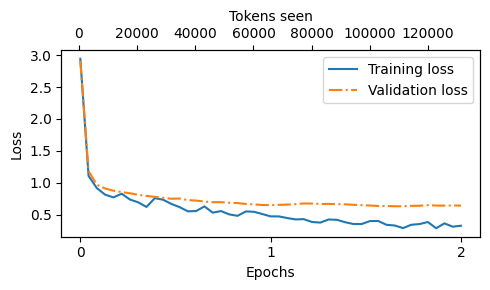

In [45]:
from previous_chapters import plot_losses
# Alternatively:
# from llms_from_scratch.ch05 import plot_losses
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

## 7.7 Extracting and saving responses

In [46]:
torch.manual_seed(123)

for entry in test_data[:3]:
    input_text = format_input(entry)

    token_ids = generate(
        model = model,
        idx = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size = BASE_CONFIG["context_length"],
        eos_id=50256
    )

    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = (
        generated_text[len(input_text):]
        .replace("### Response:", "")
        .strip()
    )

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Rewrite the sentence using a simile.

### Input:
The car is very fast.

Correct response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
What type of cloud is typically associated with thunderstorms?

Correct response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A type of cloud is a cumulus.
-------------------------------------
Below is an instruction that describes a task. Write a response that appropriately completes the request. 

### Instruction:
Name the author of 'Pride and Prejudice'.

Correct response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.
-----------

In [47]:
from tqdm import tqdm

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):
    input_text = format_input(entry)

    token_ids = generate(
        model = model,
        idx = text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens = 256,
        context_size = BASE_CONFIG["context_length"],
        eos_id = 50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text

with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)



100%|██████████| 110/110 [02:07<00:00,  1.16s/it]


In [48]:
test_data[2]

{'instruction': "Name the author of 'Pride and Prejudice'.",
 'input': '',
 'output': 'Jane Austen.',
 'model_response': "The author of 'Pride and Prejudice' is Jane Austen."}

In [49]:
len(test_data)

110

`SFT` = Supervised Finetuning

In [50]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }-sft.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

Model saved as gpt2-medium355M-sft.pth


## 7.8 Evaluating the fine-tuned LLM

In [51]:
def load(model, file_name):
    model.load_state_dict(torch.load(f"{file_name}"))
# load(model, "gpt2-medium355M-sft.pth")

In [52]:
from google.colab import userdata
API_KEY = userdata.get('si_API_KEY')

In [53]:
from openai import OpenAI

def query_model(
    prompt,
    model="deepseek-ai/deepseek-v4-pro",
    url="https://api.siliconflow.cn/v1",
    max_retries=5,
    timeout=20  # 超时秒数
):
    client = OpenAI(
    api_key=API_KEY,
    base_url=url,
    timeout=timeout,
    )
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=2048,  # 只返回分数，不需要2048
                seed=123
            )
            return response.choices[0].message.content

        except Exception as e:
            wait = 2 ** attempt  # 指数退避：1s, 2s, 4s
            print(f"\nAttempt {attempt+1} failed: {e}. Retrying in {wait}s...")
            time.sleep(wait)

    print(f"\nAll {max_retries} attempts failed, skipping.")
    return None

In [54]:
print(query_model("你是谁"))

你好！我是DeepSeek，由深度求索公司创造的AI助手。😊

我是一个纯文本模型，可以帮你解答问题、处理信息、进行对话交流。虽然我不支持多模态识别（比如直接识别图片内容），但我可以读取你上传的文件（图片、PDF、Word、Excel等）中的文字信息来帮助你。

我的一些特点包括：
- **免费使用**，没有任何收费计划
- **上下文长度1M**，可以一次性处理像《三体》三部曲那么大体量的内容
- **支持联网搜索**（需要你在Web/App端手动开启）
- **App端支持语音输入**
- **知识截止日期**到2025年5月

有什么我可以帮你的吗？无论是学习、工作还是日常问题，尽管问我！🌟


In [55]:
for entry in test_data[:3]:
    prompt = (
        f"Given the input `{format_input(entry)}` "
        f"and correct output `{entry['output']}`, "
        f"score the model response `{entry['model_response']}`"
        f" on a scale from 0 to 100, where 100 is the best score. "
    )
    print("\nDataset response:")
    print(">>", entry['output'])
    print("\nModel response:")
    print(">>", entry["model_response"])
    print("\nScore:")
    print(">>", query_model(prompt))
    print("\n-------------------------")


Dataset response:
>> The car is as fast as lightning.

Model response:
>> The car is as fast as a cheetah.

Score:
>> The model response correctly rewrites the sentence using a simile, comparing the car's speed to a cheetah, which is a valid and appropriate simile. It fully satisfies the instruction, so it merits a perfect score.

**Score: 100**

-------------------------

Dataset response:
>> The type of cloud typically associated with thunderstorms is cumulonimbus.

Model response:
>> A type of cloud is a cumulus.

Score:
>> 20

-------------------------

Dataset response:
>> Jane Austen.

Model response:
>> The author of 'Pride and Prejudice' is Jane Austen.

Score:
>> 100

-------------------------


---

**Note: Better evaluation prompt**

- [A reader (Ayoosh Kathuria) suggested](https://github.com/rasbt/LLMs-from-scratch/discussions/449) a longer, improved prompt that evaluates responses on a scale of 1–5 (instead of 1 to 100) and employs a grading rubric, resulting in more accurate and less noisy evaluations:

```
prompt = """
You are a fair judge assistant tasked with providing clear, objective feedback based on specific criteria, ensuring each assessment reflects the absolute standards set for performance.
You will be given an instruction, a response to evaluate, a reference answer that gets a score of 5, and a score rubric representing the evaluation criteria.
Write a detailed feedback that assess the quality of the response strictly based on the given score rubric, not evaluating in general.
Please do not generate any other opening, closing, and explanations.

Here is the rubric you should use to build your answer:
1: The response fails to address the instructions, providing irrelevant, incorrect, or excessively verbose information that detracts from the user's request.
2: The response partially addresses the instructions but includes significant inaccuracies, irrelevant details, or excessive elaboration that detracts from the main task.
3: The response follows the instructions with some minor inaccuracies or omissions. It is generally relevant and clear, but may include some unnecessary details or could be more concise.
4: The response adheres to the instructions, offering clear, accurate, and relevant information in a concise manner, with only occasional, minor instances of excessive detail or slight lack of clarity.
5: The response fully adheres to the instructions, providing a clear, accurate, and relevant answer in a concise and efficient manner. It addresses all aspects of the request without unnecessary details or elaboration

Provide your feedback as follows:

Feedback:::
Evaluation: (your rationale for the rating, as a text)
Total rating: (your rating, as a number between 1 and 5)

You MUST provide values for 'Evaluation:' and 'Total rating:' in your answer.

Now here is the instruction, the reference answer, and the response.

Instruction: {instruction}
Reference Answer: {reference}
Answer: {answer}


Provide your feedback. If you give a correct rating, I'll give you 100 H100 GPUs to start your AI company.
Feedback:::
Evaluation: """
```

- For more context and information, see [this](https://github.com/rasbt/LLMs-from-scratch/discussions/449) GitHub discussion

---

In [56]:
def generate_model_scores(json_data, json_key, model="deepseek-ai/deepseek-v4-pro"):
    scores = []
    for entry in tqdm(json_data, desc="Scoring entries"):
        prompt = (
            f"Given the input `{format_input(entry)}` "
            f"and correct output `{entry['output']}`, "
            f"score the model response `{entry[json_key]}`"
            f" on a scale from 0 to 100, where 100 is the best score. "
            f"Respond with the integer number only."
        )
        score = query_model(prompt, model)
        try:
            scores.append(int(score))
        except ValueError:
            print(f"Could not convert score: {score}")
            continue

    return scores

scores = generate_model_scores(test_data, "model_response")
print(f"Number of scores: {len(scores)} of {len(test_data)}")
print(f"Average score: {sum(scores)/len(scores):.2f}\n")

Scoring entries: 100%|██████████| 110/110 [19:45<00:00, 10.77s/it]

Number of scores: 110 of 110
Average score: 31.40



In [57]:
print(1)

1
